<a href="https://colab.research.google.com/github/Vivek-afk81/ml-workshop/blob/main/Pytorch_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Defining deep learning

Deep learning is a
subcategory of machine learning
focused on implementing deep neural
networks. Machine learning is a
subcategory of AI that is concerned
with algorithms that learn from data. AI
is the broader concept of machines
being able to perform tasks that
typically require human intelligence.



PyTorch (https://pytorch.org/) is an open source Python-based deep learning
library.

PyTorch (https://pytorch.org/) is an open source Python-based deep learning
library.

###The three core components of PyTorch

PyTorch is a relatively comprehensive library, and one way to approach it is to focus on
its three broad components

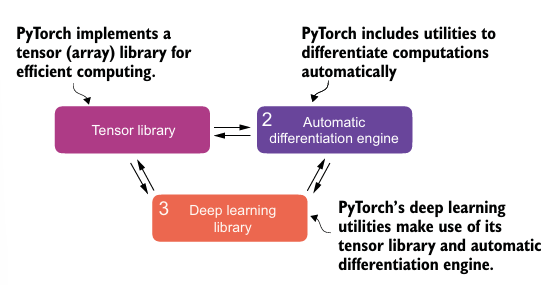

In [3]:
import torch
torch.__version__

'2.10.0+cpu'

**Tensors** represent a mathematical concept that generalizes vectors and matrices to
potentially higher dimensions.

In [6]:
##Creating Pytorch tensors

tensor0d=torch.tensor(1)
tensor1d=torch.tensor([1,2,3])
tensor2d=torch.tensor([[1,2],[3,4]])
tensor3d=torch.tensor([
    [[1,2],[3,4]],
    [[5,6],[7,8]]
])
print(tensor3d)


tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])


In [7]:
##Tensor datatypes
#PyTorch adopts the default 64-bit integer data type from Python.
tensor1d=torch.tensor([1,2,3])
print(tensor1d.dtype)

torch.int64


Tensors from  Python floats,results in tensors with a 32-bit precision
by default:

 A 32-bit floating-point number offers sufficient precision for most deep learning
tasks while consuming less memory and computational resources than a 64-bit floating
point number.

In [8]:
floatvec=torch.tensor([1.0,2.0,3.0])
print(floatvec.dtype)

torch.float32


In [9]:
#changing 64-bit integer tensor into 32 bit float tensor

floatvec=tensor1d.to(torch.float32)
print(floatvec.dtype)

torch.float32


###Common PyTorch tensor operations

In [10]:
# Create a 2D tensor
tensor2d = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

# 1. Shape of the tensor
print("Original Tensor:")
print(tensor2d)

print("\nShape of tensor:")
print(tensor2d.shape)


# 2. Reshape tensor
print("\nReshape (3 x 2) using reshape():")
reshaped = tensor2d.reshape(3, 2)
print(reshaped)


# 3. Reshape tensor using view()
print("\nReshape (3 x 2) using view():")
viewed = tensor2d.view(3, 2)
print(viewed)


# 4. Transpose tensor
print("\nTranspose using .T:")
transposed = tensor2d.T
print(transposed)


# 5. Matrix multiplication using matmul()
print("\nMatrix multiplication using matmul():")
matmul_result = tensor2d.matmul(transposed)
print(matmul_result)


# 6. Matrix multiplication using @ operator
print("\nMatrix multiplication using @ operator:")
at_result = tensor2d @ transposed
print(at_result)

Original Tensor:
tensor([[1, 2, 3],
        [4, 5, 6]])

Shape of tensor:
torch.Size([2, 3])

Reshape (3 x 2) using reshape():
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Reshape (3 x 2) using view():
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Transpose using .T:
tensor([[1, 4],
        [2, 5],
        [3, 6]])

Matrix multiplication using matmul():
tensor([[14, 32],
        [32, 77]])

Matrix multiplication using @ operator:
tensor([[14, 32],
        [32, 77]])


###Models as computation graphs

A computational graph is a directed graph that allows us to express and visualize
mathematical expressions.

A computation graph lays out the sequence of calculations needed to compute the output of neural network-
we will need this to compute the required gradients for **backpropagation**

In [11]:
##A Logistic regression forward pass

import torch.nn.functional as F
y=torch.tensor([1.0]) #True label
x1=torch.tensor([1.1]) # input feature
w1=torch.tensor([2.2]) # weight parameter
b=torch.tensor([0.0]) # bias unit
z=x1 * w1 +b          #net input
a=torch.sigmoid(z)    #activation and output
loss=F.binary_cross_entropy(a,y)

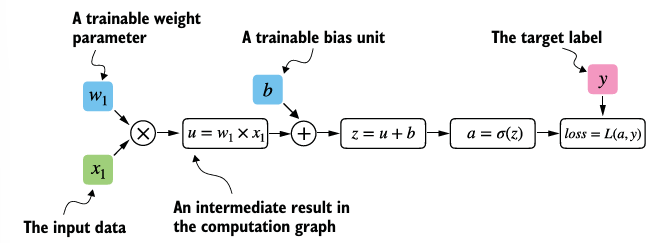

partial derivatives measures the rate at which a function
changes with respect to one of its variables. A **gradient** is a vector containing all of the
partial derivatives of a multivariate function, a function with more than one variable
as input.

 chain rule is a way to compute gradients of a loss function given the model’s
parameters in a computation graph.

This provide the info needed to update each parameter to minimize the loss function, which serves as aproxy for measuring the model's performance using a method such as gradient **descent**

###Computing gradients via autograd

PyTorch’s autograd engine
constructs a computational graph in the background by tracking every operation per
formed on tensors. Then, calling the grad function, we can compute the gradient of the
loss concerning the model parameter w1

In [15]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z=x1*w1+b
a=torch.sigmoid(z)
loss=F.binary_cross_entropy(a,y)

grad_L_w1=grad(loss,w1,retain_graph=True)
grad_L_b=grad(loss,b,retain_graph=True)
# loss.backward() we can call .backward on the loss, and PyTorch will compute the gradients of all the leaf nodes in the graph
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)
